# Reinforcement Learning, Step by Step

In reinforcement learning, a computer learns by **trial and error**. It tries something, gets a **score**, and
slowly learns which choices lead to higher scores. Nobody ever tells it the right answer.

In this notebook we build everything from scratch, one step at a time:

1. a tiny world for a robot to live in
2. a robot that moves at random, so we can see where we start
3. the idea of adding up rewards (the **return**)
4. a table of scores the robot learns (the **Q-table**)
5. how the robot chooses what to do (**explore or exploit**)
6. how it updates its scores after every move (**Q-learning**)
7. training it, and watching it improve
8. looking at what it has learned

There is no scikit-learn here: reinforcement learning is just a loop that we can write ourselves.

Run each cell in order with Shift + Enter.

## The key words

| Word | Meaning | In our example |
|---|---|---|
| **Agent** | The learner that makes decisions | The robot |
| **Environment** | The world the agent acts in | A 4 × 4 grid |
| **State** | The current situation | Which square the robot is on |
| **Action** | A choice the agent can make | Move up, down, left or right |
| **Reward** | A number saying how good that was | +10, −10 or −1 |
| **Episode** | One attempt, from start to finish | One trip from the start to the goal or the trap |
| **Policy** | The agent's rule for choosing actions | Which way to move on each square |

## 1. Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)   # fixed random numbers, so everyone gets the same results

---
## 2. Building the world (the environment)

The robot lives on a 4 × 4 grid. We name the squares A to P, row by row.

```
A  B  C  D        D = goal  (+10, the episode ends)
E  F  G  H        F = wall  (cannot go there)
I  J  K  L        H = trap  (-10, the episode ends)
M  N  O  P        M = start
```

Every other move costs **−1**. That small penalty is what makes shorter routes better.

In [2]:
LETTERS = "ABCDEFGHIJKLMNOP"
GOAL, TRAP, WALL, START = "D", "H", "F", "M"
ACTIONS = ["up", "down", "left", "right"]
MOVES = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

def position(square):
    """Turn a letter into (row, column). For example 'M' -> (3, 0)."""
    i = LETTERS.index(square)
    return i // 4, i % 4

def square_at(row, col):
    """Turn (row, column) back into a letter."""
    return LETTERS[row * 4 + col]

### The step function

This is the most important part of the environment. Give it the square the robot is on and the action it
chooses, and it returns three things:

- the **new square**
- the **reward**
- whether the episode is **done**

If the robot tries to walk off the edge or into the wall, it stays where it is (and still pays −1).

In [3]:
def step(square, action):
    row, col = position(square)
    d_row, d_col = MOVES[action]
    new_row, new_col = row + d_row, col + d_col

    # off the edge, or into the wall: stay put
    if not (0 <= new_row < 4 and 0 <= new_col < 4) or square_at(new_row, new_col) == WALL:
        new_row, new_col = row, col

    new_square = square_at(new_row, new_col)
    if new_square == GOAL:
        return new_square, 10, True
    if new_square == TRAP:
        return new_square, -10, True
    return new_square, -1, False

Let's try a few moves by hand to check it works.

In [4]:
print(step("M", "up"))      # M to I: an ordinary move
print(step("M", "left"))    # off the edge: stays on M
print(step("E", "right"))   # into the wall: stays on E
print(step("C", "right"))   # into the goal
print(step("G", "right"))   # into the trap

('I', -1, False)
('M', -1, False)
('E', -1, False)
('D', 10, True)
('H', -10, True)


Each line shows `(new square, reward, done)`. Moving into the goal gives **+10** and ends the episode; moving into
the trap gives **−10** and ends it too.

### Drawing the grid

A helper to draw the grid. It can also write something on each square, which we will use later to show what the
robot has learned.

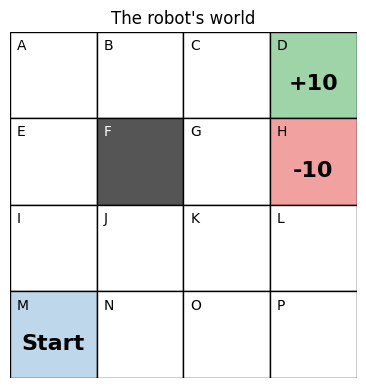

In [5]:
def draw_grid(labels=None, title=""):
    colours = {GOAL: "#9FD3A8", TRAP: "#F2A1A1", WALL: "#555555", START: "#BFD7EA"}
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for s in LETTERS:
        r, c = position(s)
        ax.add_patch(plt.Rectangle((c, 3 - r), 1, 1, facecolor=colours.get(s, "white"), edgecolor="black"))
        ax.text(c + 0.08, 3 - r + 0.8, s, fontsize=10, color="white" if s == WALL else "black")
        text = {GOAL: "+10", TRAP: "-10", WALL: ""}.get(s, labels.get(s, "") if labels else "")
        ax.text(c + 0.5, 3 - r + 0.4, text, ha="center", va="center", fontsize=16, fontweight="bold")
    ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title)
    plt.show()

draw_grid({"M": "Start"}, title="The robot's world")

**Question:** what is the shortest route from M to D? (Answer: 6 moves. There are two of them.)

---
## 3. A robot that knows nothing

Before any learning, the best the robot can do is pick moves **at random**. Let's see how badly that goes. We run
10,000 episodes and record how many moves each one took and how it ended.

In [6]:
def random_episode():
    square, moves, total_reward = START, 0, 0
    done = False
    while not done:
        action = str(rng.choice(ACTIONS))
        square, reward, done = step(square, action)
        moves += 1
        total_reward += reward
    return moves, total_reward, square

results = [random_episode() for _ in range(10000)]
moves = [r[0] for r in results]
rewards = [r[1] for r in results]
trap_share = np.mean([r[2] == TRAP for r in results])

print(f"Average moves to finish: {np.mean(moves):.1f}")
print(f"Ended in the trap:       {trap_share:.0%}")
print(f"Average total reward:    {np.mean(rewards):.1f}")

Average moves to finish: 42.0
Ended in the trap:       72%
Average total reward:    -45.4


A random robot takes about **42 moves**, compared with 6 on the best route, and falls into the trap most of the
time. This is where every reinforcement learner starts. The rest of the notebook is about how it learns from
these rewards to do better.

---
## 4. Adding up rewards: the return

The robot's goal is not just the next reward, but the **total** reward from now until the end of the episode. This
total is called the **return**.

We also **discount** rewards that are further in the future: a reward one step away counts in full, the next is
multiplied by **γ** (gamma, here 0.9), the next by 0.9 × 0.9 = 0.81, and so on. Sooner rewards count for more.

In [7]:
def discounted_return(rewards, gamma=0.9):
    total = 0
    for k, r in enumerate(rewards):
        total += (gamma ** k) * r
    return total

# Starting on E, the robot goes up, right, right, right: -1, -1, -1, then +10 for the goal
rewards = [-1, -1, -1, 10]
print("Without discounting:", sum(rewards))
print("With gamma = 0.9:   ", round(discounted_return(rewards), 2))

Without discounting: 7
With gamma = 0.9:    4.58


With discounting the return is **4.58**: −1 − 0.9 − 0.81 + 7.29. A longer route collects more −1s **and** shrinks
the +10 more, so the robot has two reasons to be quick.

---
## 5. The Q-table: a score for every square and move

Q-learning keeps a table with one score for every **square** and **action**. The score, called a **Q-value**,
answers:

> "If I am on this square and make this move, how much return can I expect?"

At the start the robot knows nothing, so every score is **0**. The goal and trap squares are not included,
because the episode ends there.

In [8]:
squares = [s for s in LETTERS if s not in (GOAL, TRAP, WALL)]
Q = {(s, a): 0.0 for s in squares for a in ACTIONS}

def show_q(Q, rows=squares):
    table = pd.DataFrame([[Q[(s, a)] for a in ACTIONS] for s in rows], index=rows, columns=ACTIONS)
    return table.round(2)

print(len(Q), "scores in the table")
show_q(Q)

52 scores in the table


,up,down,left,right
A,0.0,0.0,0.0,0.0
B,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0
G,0.0,0.0,0.0,0.0
I,0.0,0.0,0.0,0.0
J,0.0,0.0,0.0,0.0
K,0.0,0.0,0.0,0.0
L,0.0,0.0,0.0,0.0
M,0.0,0.0,0.0,0.0


13 squares × 4 moves = **52 scores**, all 0. Once the table is learned, the robot's **policy** is simple: on each
square, choose the move with the highest score in that row.

---
## 6. Choosing a move: explore or exploit?

If the robot always picks the move with the best score so far (**exploiting**), it can get stuck with its first
idea and never discover anything better. So sometimes it should try something random (**exploring**).

The simple rule is called **epsilon-greedy**:

- with probability **ε** (epsilon, here 0.1), pick a **random** move
- otherwise, pick the move with the **highest score** (if there is a tie, pick one of the best at random)

In [9]:
def choose_action(Q, square, epsilon=0.1):
    if rng.random() < epsilon:
        return str(rng.choice(ACTIONS))                  # explore
    scores = [Q[(square, a)] for a in ACTIONS]
    best = max(scores)
    best_actions = [a for a, s in zip(ACTIONS, scores) if s == best]
    return str(rng.choice(best_actions))                 # exploit

print([choose_action(Q, "M") for _ in range(8)])

['down', 'right', 'up', 'left', 'up', 'down', 'down', 'left']


Right now every score is 0, so all moves tie and the choice is random. That changes as the scores are learned.

---
## 7. Learning from one move: the update rule

After every single move, the robot updates **one** score: the one for the square it was on and the move it made.

In words:

> new score = old score + α × (what just happened − old score)
>
> where **what just happened** = reward + γ × (best score on the new square)

- **α** (alpha) is the **learning rate**: how big a nudge to make. We use 0.5, which means "move halfway".
- **γ** (gamma) is the discount from before, 0.9.
- If the episode has ended, there is no new square to look ahead to, so that part counts as 0.

The clever part is that the robot does not wait until the end of the episode. It uses its own scores for the new
square as a guess of what comes next.

In [10]:
ALPHA, GAMMA = 0.5, 0.9

def update(Q, square, action, reward, new_square, done):
    old = Q[(square, action)]
    best_next = 0 if done else max(Q[(new_square, a)] for a in ACTIONS)
    what_happened = reward + GAMMA * best_next
    Q[(square, action)] = old + ALPHA * (what_happened - old)
    return old, Q[(square, action)]

### Working through it by hand

Let's do two updates ourselves on a fresh table, and check them against the code.

**Update 1:** the robot is on **C** and moves **right** into the goal. Reward +10, episode over.

- what just happened = 10 + 0.9 × 0 = 10
- new score = 0 + 0.5 × (10 − 0) = **5**

In [11]:
Q_demo = {(s, a): 0.0 for s in squares for a in ACTIONS}

new_square, reward, done = step("C", "right")
print("Q(C, right):", update(Q_demo, "C", "right", reward, new_square, done))

Q(C, right): (0.0, 5.0)


**Update 2:** later, the robot is on **G** and moves **up** into C. Reward −1. The best score on C is now 5.

- what just happened = −1 + 0.9 × 5 = 3.5
- new score = 0 + 0.5 × (3.5 − 0) = **1.75**

In [12]:
new_square, reward, done = step("G", "up")
print("Q(G, up):", update(Q_demo, "G", "up", reward, new_square, done))

Q(G, up): (0.0, 1.75)


Square G has **never** touched the goal, but it has learned that moving up is good, **because C is good**. Every
episode, the good news spreads one step further back from the goal towards the start.

---
## 8. Watching one episode in detail

Now let's put the pieces together and watch the robot's very first episode, move by move, with an empty table.
Each line shows where it was, what it did, the reward, where it ended up, and how the score changed.

In [13]:
Q = {(s, a): 0.0 for s in squares for a in ACTIONS}

def run_episode(Q, epsilon=0.1, show=False):
    square, moves, total = START, 0, 0
    done = False
    while not done:
        action = choose_action(Q, square, epsilon)
        new_square, reward, done = step(square, action)
        old, new = update(Q, square, action, reward, new_square, done)
        if show:
            print(f"{square} --{action:>5}--> {new_square}   reward {reward:+3d}   Q({square},{action}): {old:6.2f} -> {new:6.2f}")
        square = new_square
        moves += 1
        total += reward
    return moves, total, square

moves, total, end = run_episode(Q, show=True)
print(f"\nFinished on {end} after {moves} moves, total reward {total}")

M -- left--> M   reward  -1   Q(M,left):   0.00 ->  -0.50
M --   up--> I   reward  -1   Q(M,up):   0.00 ->  -0.50
I -- down--> M   reward  -1   Q(I,down):   0.00 ->  -0.50
M --right--> N   reward  -1   Q(M,right):   0.00 ->  -0.50
N -- down--> N   reward  -1   Q(N,down):   0.00 ->  -0.50
N --right--> O   reward  -1   Q(N,right):   0.00 ->  -0.50
O --   up--> K   reward  -1   Q(O,up):   0.00 ->  -0.50
K --   up--> G   reward  -1   Q(K,up):   0.00 ->  -0.50
G --   up--> C   reward  -1   Q(G,up):   0.00 ->  -0.50
C -- down--> G   reward  -1   Q(C,down):   0.00 ->  -0.50
G -- down--> K   reward  -1   Q(G,down):   0.00 ->  -0.50
K -- down--> O   reward  -1   Q(K,down):   0.00 ->  -0.50
O -- left--> N   reward  -1   Q(O,left):   0.00 ->  -0.50
N -- left--> M   reward  -1   Q(N,left):   0.00 ->  -0.50
M -- down--> M   reward  -1   Q(M,down):   0.00 ->  -0.50
M -- left--> M   reward  -1   Q(M,left):  -0.50 ->  -0.97
M --right--> N   reward  -1   Q(M,right):  -0.50 ->  -0.75
N -- left--> M   re

Most of the scores went **down**, because almost every move costs −1. That is useful information: the robot is
learning which moves wasted time. Only the very last move, if it reached the goal, got a big positive update.

---
## 9. Training: lots of episodes

One episode teaches very little. Let's run **150 episodes**, starting from an empty table, and record how many
moves each one took.

In [14]:
Q = {(s, a): 0.0 for s in squares for a in ACTIONS}

history = []
for episode in range(150):
    moves, total, end = run_episode(Q, epsilon=0.1)
    history.append(moves)

print("First 10 episodes:", history[:10])
print("Last 10 episodes: ", history[-10:])

First 10 episodes: [66, 30, 20, 21, 7, 28, 16, 6, 11, 6]
Last 10 episodes:  [7, 7, 7, 6, 6, 6, 6, 8, 7, 6]


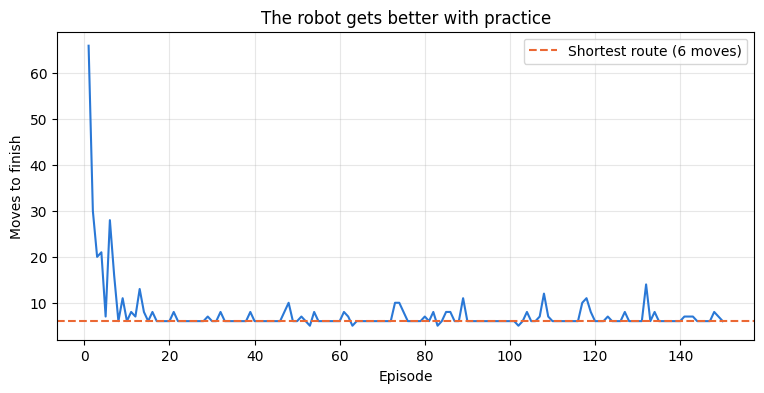

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, 151), history, color="#2a78d6")
plt.axhline(6, color="#eb6834", linestyle="--", label="Shortest route (6 moves)")
plt.xlabel("Episode")
plt.ylabel("Moves to finish")
plt.title("The robot gets better with practice")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The early episodes are long and messy. After a few dozen episodes the robot is finishing in about 6 moves. It
does not always take exactly 6, because 10% of the time it still makes a random move to keep exploring.

---
## 10. What has the robot learned?

### The Q-table

Here are the learned scores. In each row, the **highest** number is the move the robot now prefers.

In [16]:
show_q(Q, rows=["M", "K", "G", "C", "L"])

,up,down,left,right
M,1.81,-1.19,0.52,1.41
K,6.20,0.79,2.82,-0.61
G,8.00,3.15,4.41,-9.84
C,7.50,6.01,5.92,10.00
L,-5.00,-1.58,3.09,-1.65


Things to notice:

- On **C**, moving **right** scores about 10, because it reaches the goal straight away.
- On **G**, moving **right** scores about −10, because it falls in the trap. The robot has learned to avoid it.
- On **M**, the start, the best moves score less, because the goal is 6 moves away and every move costs −1.

### The policy as arrows

Pick the best move on every square and draw it as an arrow.

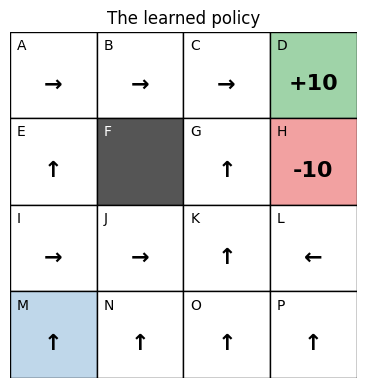

In [17]:
ARROWS = {"up": "↑", "down": "↓", "left": "←", "right": "→"}

def best_action(Q, square):
    return max(ACTIONS, key=lambda a: Q[(square, a)])

policy = {s: ARROWS[best_action(Q, s)] for s in squares}
draw_grid(policy, title="The learned policy")

Follow the arrows from M and you should reach the goal in 6 moves, steering around the trap. Squares the robot
rarely visits, such as P, may have less sensible arrows, because it has had little practice there.

### Testing the trained robot

Finally, switch exploring **off** (ε = 0) and let the robot follow its policy from the start.

In [18]:
square, route = START, [START]
for _ in range(20):                      # a safety limit, in case it ever loops
    square, reward, done = step(square, best_action(Q, square))
    route.append(square)
    if done:
        break

print(" -> ".join(route))
print("Moves:", len(route) - 1)

M -> I -> J -> K -> G -> C -> D
Moves: 6


---
## 11. Summary

| Step | What happens |
|---|---|
| **Environment** | `step(square, action)` returns the new square, the reward and whether the episode is over |
| **Return** | The total reward from now on, with future rewards discounted by γ |
| **Q-table** | A score for every square and move, starting at 0 |
| **Choosing** | Epsilon-greedy: usually the best-scoring move, sometimes a random one |
| **Updating** | After every move: new score = old + α × (reward + γ × best next score − old) |
| **Training** | Repeat for many episodes; the good news spreads back from the goal |
| **Policy** | On each square, take the move with the highest score |

## 12. Things to try

Change the values below, then re-run the training cell (Section 9) and the cells after it.

1. Set `epsilon=0` in the training loop, so the robot **never explores**. Does it still learn the shortest route?
   How long do the early episodes take?
2. Change `GAMMA` to 0.5. What happens to the scores on squares far from the goal, such as M?
3. In `step`, change the −1 for an ordinary move to **0**. Does the robot still find the **shortest** route? Why
   might it not?
4. Make the trap much worse, −100. Does the policy near the trap change?
5. Change `ALPHA` to 0.1. Does the robot learn faster or slower?

In [19]:
# Your experiments here